# 05 -- Visual Sudoku LP-M3N (main experiment)

## 0. Colab bootstrap (no-op locally)

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    import sys, os
    PROJECT_ROOT = '/content/drive/MyDrive/Master-thesis'
    if PROJECT_ROOT not in sys.path:
        sys.path.insert(0, PROJECT_ROOT)
    os.chdir(PROJECT_ROOT + '/notebooks')
    print('Colab setup done -- cwd:', os.getcwd())
except ImportError:
    print('Local run -- Colab bootstrap skipped')

Mounted at /content/drive
Colab setup done -- cwd: /content/drive/MyDrive/Master-thesis/notebooks


## 1. Setup

In [ ]:
import json
import os
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'mnlearn').is_dir():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError('could not locate project root')
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)

from mnlearn.config import load_config
from mnlearn.data import build_datasets, load_sudoku_benchmark
from mnlearn.experiments import collect_results
from mnlearn.learning import train
from mnlearn.models import build_model

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RUN_TAG    = 'vis_sudoku_main'
RESULTS    = REPO_ROOT / 'results' / RUN_TAG
THESIS_FIG = REPO_ROOT / 'thesis' / 'figures' / RUN_TAG
THESIS_TBL = REPO_ROOT / 'thesis' / 'tables'
THESIS_FIG.mkdir(parents=True, exist_ok=True)
THESIS_TBL.mkdir(parents=True, exist_ok=True)

BASE_CONFIG = load_config(REPO_ROOT / 'configs' / 'experiments' / 'lpm3n_visual_sudoku.yaml')
print(f'DEVICE = {DEVICE}')

DEVICE = cuda


In [3]:
def out_dir(n, wd, seed):
    return RESULTS / f'run_n{n}_wd{wd:g}_seed{seed}'


## 2. Lambda sweep at N=500 (3 seeds)

In [ ]:
LAMBDAS = [1e-4, 1e-3, 5e-3, 1e-2]
SEEDS   = [0, 1, 2]
N_LC    = 500   # N used for the lambda check



for wd in LAMBDAS:
    for seed in SEEDS:
        d = out_dir(N_LC, wd, seed)
        if (d / 'results.json').exists():
            print(f'skip: {d.name}')
            continue
        name = f'{RUN_TAG}/{d.name}'
        cfg = replace(
            BASE_CONFIG,
            experiment=replace(BASE_CONFIG.experiment, name=name, seed=seed),
            data=replace(BASE_CONFIG.data, train_size=N_LC),
            training=replace(BASE_CONFIG.training,
                             optimizer=replace(BASE_CONFIG.training.optimizer, weight_decay=wd)),
        )
        print(f'running: {name}')
        train(cfg)

print('\nlambda sweep done.')

running: vis_sudoku_main_lrpw/run_n500_wd0.0001_seed0
[run] vis_sudoku_main_lrpw/run_n500_wd0.0001_seed0  device=cuda  output=results/vis_sudoku_main_lrpw/run_n500_wd0.0001_seed0
  Epoch   1:  train_loss=141.5322  hamming=0.8890  zero_one=1.0000  phi_norm=0.5320
  Epoch   5:  train_loss=90.6565  hamming=0.8866  zero_one=1.0000  phi_norm=1.1555
  Epoch  10:  train_loss=40.1365  hamming=0.6844  zero_one=1.0000  phi_norm=1.6489
  Epoch  15:  train_loss=21.4751  hamming=0.5350  zero_one=1.0000  phi_norm=1.9979
  Epoch  20:  train_loss=14.6085  hamming=0.4494  zero_one=1.0000  phi_norm=2.0801
  Epoch  25:  train_loss=11.8144  hamming=0.4014  zero_one=1.0000  phi_norm=2.0643
  Epoch  30:  train_loss=10.1880  hamming=0.3814  zero_one=1.0000  phi_norm=2.0259
  Epoch  35:  train_loss=8.9972  hamming=0.3626  zero_one=1.0000  phi_norm=1.9715
  Epoch  40:  train_loss=8.0258  hamming=0.3407  zero_one=1.0000  phi_norm=1.9142
  Epoch  45:  train_loss=7.2776  hamming=0.3248  zero_one=0.9999  phi_norm=

In [ ]:
df_lc = collect_results(str(RESULTS / f'run_n{N_LC}_wd*_seed*/'))
df_lc = df_lc[(df_lc['loss'] == 'lp_m3n') & (df_lc['n'] == N_LC)].copy()
df_lc = df_lc[df_lc['wd'].isin(LAMBDAS) & df_lc['seed'].isin(SEEDS)]
df_lc = df_lc[['wd', 'seed', 'hamming', 'zero_one']].sort_values(['wd', 'seed']).reset_index(drop=True)
df_lc.to_csv(THESIS_TBL / 's5_3_2_lambda_sweep.csv', index=False)

agg_lc = df_lc.groupby('wd')[['hamming', 'zero_one']].agg(['mean', 'std', 'count']).reset_index()
agg_lc.columns = ['_'.join([c for c in col if c]).rstrip('_') for col in agg_lc.columns]
print(agg_lc.to_string(index=False))

BEST_LAMBDA = float(agg_lc.loc[agg_lc['zero_one_mean'].idxmin(), 'wd'])
print(f'\nBEST_LAMBDA (lowest mean 0/1 at N={N_LC}): {BEST_LAMBDA:g}')

    wd  hamming_mean  hamming_std  hamming_count  zero_one_mean  zero_one_std  zero_one_count
0.0001      0.063166     0.077322              3       0.347833      0.342920               3
0.0010      0.062770     0.078306              3       0.347600      0.347904               3
0.0050      0.112021     0.086331              3       0.564367      0.400342               3
0.0100      0.111945     0.085338              3       0.568200      0.395145               3

BEST_LAMBDA (lowest mean 0/1 at N=500): 0.001


## 3. Lambda sweep figure

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, metric, ylabel in zip(axes, ('hamming', 'zero_one'), ('test Hamming', 'test 0/1')):
    g = df_lc.groupby('wd')[metric].agg(['mean', 'std']).reset_index().sort_values('wd')
    line, = ax.plot(g['wd'], g['mean'], label='LP-M3N')
    ax.fill_between(g['wd'],
                    g['mean'] - g['std'].fillna(0.0),
                    g['mean'] + g['std'].fillna(0.0),
                    alpha=0.2, color=line.get_color())
    ax.axvline(BEST_LAMBDA, color='red', linestyle=':',
               label=f'BEST_LAMBDA = {BEST_LAMBDA:g}')
    ax.set_xscale('log')
    ax.set_xlabel('weight_decay (lambda)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} vs lambda at N={N_LC}')
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)

fig.tight_layout()
fig.savefig(THESIS_FIG / 'lambda_sweep.png', bbox_inches='tight', dpi=150)

## 4. Learning curve at BEST_LAMBDA (6 seeds)

In [ ]:
N_VALUES = [100,500,1500,5000]
LAMBDA_PER_N = {100: 5e-3,500: 5e-3, 1500: 1e-3, 5000: 1e-3}
SEEDS = [0,1,2,4,5,6]

def out_dir(n, wd, seed):
    return RESULTS / f'run_n{n}_wd{wd:g}_seed{seed}'

for seed in SEEDS:
    for n in N_VALUES:
        wd = LAMBDA_PER_N[n]
        d = out_dir(n, wd, seed)
        if (d / 'results.json').exists():
            print(f'skip: {d.name}')
            continue
        name = f'{RUN_TAG}/{d.name}'
        cfg = replace(
            BASE_CONFIG,
            experiment=replace(BASE_CONFIG.experiment, name=name, seed=seed),
            data=replace(BASE_CONFIG.data, train_size=n),
            training=replace(BASE_CONFIG.training,
                             optimizer=replace(BASE_CONFIG.training.optimizer, weight_decay=wd)),
        )
        print(f'running: {name}')
        train(cfg)

print('\nN sweep done.')


running: vis_sudoku_main_lrpw_v2/run_n100_wd0.005_seed0
[run] vis_sudoku_main_lrpw_v2/run_n100_wd0.005_seed0  device=cuda  output=results/vis_sudoku_main_lrpw_v2/run_n100_wd0.005_seed0
  Epoch   1:  train_loss=145.3757  hamming=0.8889  zero_one=1.0000  phi_norm=0.5186
  Epoch  10:  train_loss=37.7065  hamming=0.8882  zero_one=1.0000  phi_norm=1.2610
  Epoch  20:  train_loss=22.9092  hamming=0.5881  zero_one=1.0000  phi_norm=1.2989
  Epoch  30:  train_loss=17.4229  hamming=0.3565  zero_one=0.9648  phi_norm=1.6090
  Epoch  40:  train_loss=15.6646  hamming=0.2411  zero_one=0.8908  phi_norm=1.7750
  Epoch  50:  train_loss=15.1284  hamming=0.2027  zero_one=0.8323  phi_norm=1.8880
  Epoch  60:  train_loss=14.7907  hamming=0.1507  zero_one=0.7365  phi_norm=1.9681
  Epoch  70:  train_loss=14.8836  hamming=0.1216  zero_one=0.6388  phi_norm=2.0402
  Epoch  80:  train_loss=15.0399  hamming=0.0956  zero_one=0.5386  phi_norm=2.1025
  Epoch  90:  train_loss=15.2488  hamming=0.1086  zero_one=0.5867  

## 5. Headline table

In [ ]:
BEST_LAMBDA = 5e-3
N_VALUES = [100]
SEEDS = [0, 1, 2,4,5,6]
df = collect_results(str(RESULTS / f'run_n*_wd{BEST_LAMBDA:g}_seed*/'))
df = df[(df['loss'] == 'lp_m3n') & df['n'].isin(N_VALUES) & df['seed'].isin(SEEDS) & (df['wd'] == BEST_LAMBDA)].copy()
df = df[['n', 'seed', 'hamming', 'zero_one', 'best_epoch', 'final_epoch', 'total_seconds']]
df = df.sort_values(['n', 'seed']).reset_index(drop=True)
df.to_csv(THESIS_TBL / 's5_3_4_learning_curve.csv', index=False)

agg = df.groupby('n')[['hamming', 'zero_one']].agg(['mean', 'std', 'count']).reset_index()
agg.columns = ['_'.join([c for c in col if c]).rstrip('_') for col in agg.columns]
print(agg.to_string(index=False))
agg.to_csv(THESIS_TBL / 's5_3_4_tightness.csv', index=False)

                  n  hamming_mean  hamming_std  hamming_count  zero_one_mean  zero_one_std  zero_one_count
                500      0.014740          NaN            1.0        0.10630           NaN               1
               1500      0.007782     0.001647            6.0        0.05635       0.01097               6
               5000      0.006118     0.000687            5.0        0.05066       0.00499               5
Franc 2021 (N=1500)           NaN          NaN            NaN        0.10000       0.02900               5


## 6. Learning curve figure

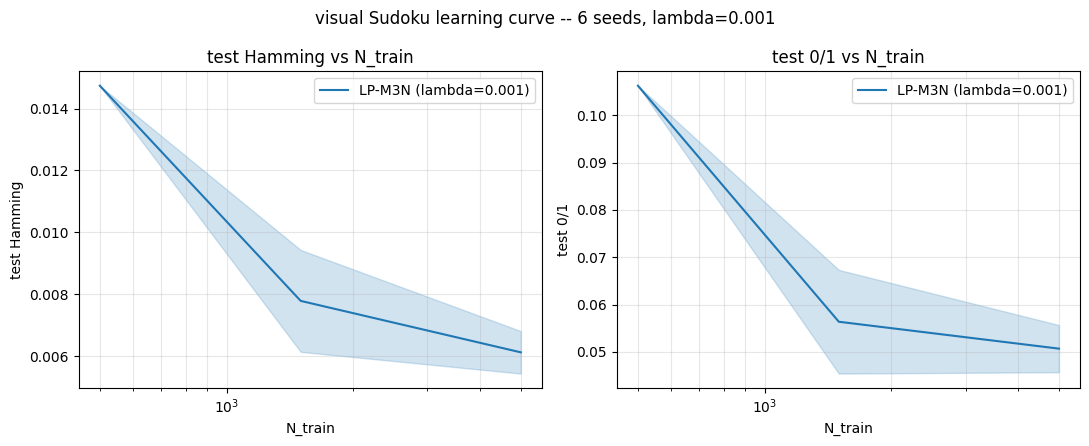

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, metric, ylabel in zip(axes, ('hamming', 'zero_one'), ('test Hamming', 'test 0/1')):
    g = df.groupby('n')[metric].agg(['mean', 'std']).reset_index().sort_values('n')
    line, = ax.plot(g['n'], g['mean'], label=f'LP-M3N (lambda={BEST_LAMBDA:g})')
    ax.fill_between(g['n'],
                    g['mean'] - g['std'].fillna(0.0),
                    g['mean'] + g['std'].fillna(0.0),
                    alpha=0.2, color=line.get_color())
    ax.set_xscale('log')
    ax.set_xlabel('N_train')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} vs N_train')
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)

fig.suptitle(f'visual Sudoku learning curve -- {len(SEEDS)} seeds, lambda={BEST_LAMBDA:g}')
fig.tight_layout()
fig.savefig(THESIS_FIG / 'learning_curve.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Per-epoch trajectory (largest N, seed 0)

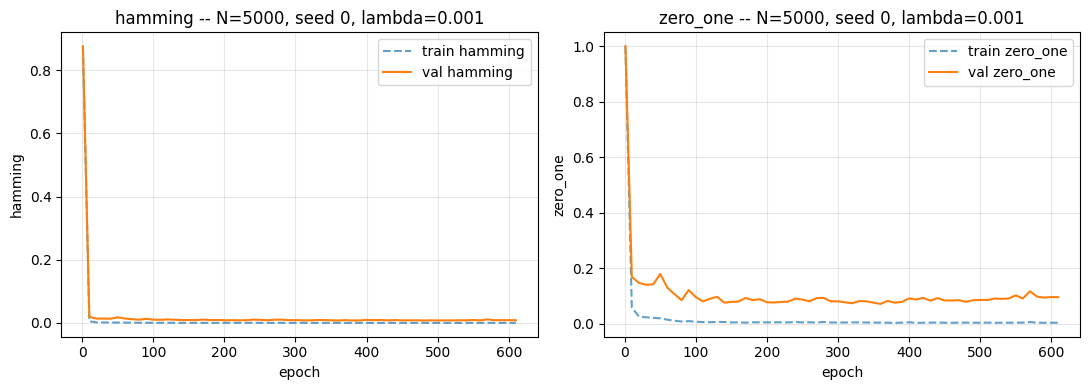

In [6]:
N_BIG = max(N_VALUES)
history = json.loads((out_dir(N_BIG, BEST_LAMBDA, SEEDS[0]) / 'history.json').read_text())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric in zip(axes, ('hamming', 'zero_one')):
    train_m = [m[metric] for m in history['train_metrics']]
    val_m   = [m[metric] for m in history['val_metrics']]
    ax.plot(history['epoch'], train_m, linestyle='--', alpha=0.7, label=f'train {metric}')
    ax.plot(history['epoch'], val_m, label=f'val {metric}')
    ax.set_xlabel('epoch')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} -- N={N_BIG}, seed {SEEDS[0]}, lambda={BEST_LAMBDA:g}')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(THESIS_FIG / 'per_epoch.png', bbox_inches='tight', dpi=150)
plt.show()

## 8. Learned unary and pairwise scores (Franc 2021 figure (c)-(d) style)

Unary for the CNN backbone: `f_v(x, y) = mean unary score for class y over all test clue cells whose true digit is x`. Computed by forward-passing the test images through the trained CNN and aggregating by clue digit.

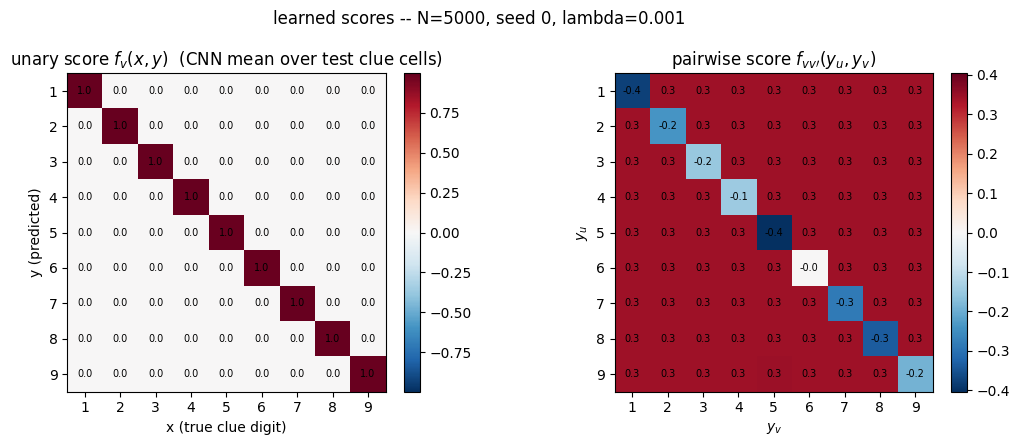

In [ ]:
model, edges = build_model(BASE_CONFIG.architecture, base_dir=REPO_ROOT)
sd = torch.load(out_dir(N_BIG, BEST_LAMBDA, SEEDS[0]) / 'model.pt', weights_only=True)
model.load_state_dict(sd)
model = model.to(DEVICE).eval()

test_X, _ = build_datasets(BASE_CONFIG.data, base_dir=REPO_ROOT)['test']
bench_test = load_sudoku_benchmark(
    str(REPO_ROOT / 'benchmarks' / 'sudoku'),
    mode='visual',
    mnist_root=str(REPO_ROOT / 'mnist_data'),
)['test']
quizzes = bench_test.quizzes[:test_X.shape[0]]

K = 9
unary_sum   = np.zeros((K, K))
unary_count = np.zeros(K, dtype=np.int64)

with torch.no_grad():
    for i in range(0, test_X.shape[0], 64):
        u = model.unary(test_X[i:i + 64].to(DEVICE)).cpu().numpy()  # [B, 81, 9]
        q = quizzes[i:i + 64].numpy()                                # [B, 81]
        for d in range(1, K + 1):
            mask = q == d
            if mask.any():
                unary_sum[d - 1]   += u[mask].sum(axis=0)
                unary_count[d - 1] += mask.sum()

unary_per_digit = unary_sum / np.maximum(unary_count[:, None], 1)  # [9 true digits, 9 predicted]
unary_heatmap   = unary_per_digit.T                                 # rows=predicted y, cols=true x
W_pairwise      = sd['pairwise'].cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

vmax_u = float(np.abs(unary_heatmap).max())
im0 = axes[0].imshow(unary_heatmap, cmap='RdBu_r', vmin=-vmax_u, vmax=vmax_u)
for (i, j), v in np.ndenumerate(unary_heatmap):
    axes[0].text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=7)
axes[0].set_xticks(range(K))
axes[0].set_yticks(range(K))
axes[0].set_xticklabels(range(1, K + 1))
axes[0].set_yticklabels(range(1, K + 1))
axes[0].set_xlabel('x (true clue digit)')
axes[0].set_ylabel('y (predicted)')
axes[0].set_title('unary score $f_v(x, y)$  (CNN mean over test clue cells)')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

vmax_p = float(np.abs(W_pairwise).max())
im1 = axes[1].imshow(W_pairwise, cmap='RdBu_r', vmin=-vmax_p, vmax=vmax_p)
for (i, j), v in np.ndenumerate(W_pairwise):
    axes[1].text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=7)
axes[1].set_xticks(range(K))
axes[1].set_yticks(range(K))
axes[1].set_xticklabels(range(1, K + 1))
axes[1].set_yticklabels(range(1, K + 1))
axes[1].set_xlabel(r'$y_v$')
axes[1].set_ylabel(r'$y_u$')
axes[1].set_title(r'pairwise score $f_{vv\prime}(y_u, y_v)$')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

fig.suptitle(f'learned scores -- N={N_BIG}, seed {SEEDS[0]}, lambda={BEST_LAMBDA:g}')
fig.tight_layout()
fig.savefig(THESIS_FIG / 'learned_scores.png', bbox_inches='tight', dpi=150)
plt.show()